# Predição de Ações do Banco do Brasil (BBAS3) com MLP

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Data load

In [9]:
def get_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)

    return data

ticker_bb = "BBAS3.SA"
ticker_itau = "ITUB4.SA"
data_banco_brasil = get_data(ticker_bb, "2020-01-01", "2023-12-31")

display(data_banco_brasil.head())

/tmp/ipykernel_27864/2461344390.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
/home/anderson/miniconda3/envs/intelligent_systems/lib/python3.11/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BBAS3.SA,BBAS3.SA,BBAS3.SA,BBAS3.SA,BBAS3.SA
Date,,,,,
2020-01-02,17.015810,17.069578,16.816554,16.873484,26319800
2020-01-03,16.987350,17.050607,16.715350,16.794420,18930800
2020-01-06,16.762785,16.889297,16.588832,16.889297,19999800
2020-01-07,16.636272,16.772272,16.538227,16.762784,21277000
2020-01-08,16.484461,16.759624,16.459159,16.686879,42937200


## Data transform


In [12]:
def transform_data(data, window=5):
    df = data[["Close"]].copy()

    for i in range(1, window + 1):
        df[f"fechamento_atraso_{i}"] = df["Close"].shift(i)

    df.dropna(inplace=True)
    X = df.drop(columns=["Close"])
    y = df["Close"]

    return X, y

attributes, target = transform_data(data_banco_brasil)

# Divisão entre treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(attributes, target, test_size=0.2, shuffle=False)

# Normalização
normalizer = StandardScaler()
X_train_scaled = normalizer.fit_transform(X_train)
X_test_scaled = normalizer.transform(X_test)



## Model MLP

In [ ]:
model_tf = Sequential([
    Dense(100, activation="relu", input_dim=X_train_scaled.shape[1]),
    Dense(50, activation="relu"),
    Dense(1) # Camada de saída
])

model_tf.compile(optimizer="adam", loss="mean_squared_error")


/home/anderson/miniconda3/envs/intelligent_systems/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1788199945.395454   27864 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5803 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


## Train

In [14]:
history = model_tf.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/100


I0000 00:00:1788200000.598704   33614 service.cc:153] XLA service 0x7b30080306d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788200000.598767   33614 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1788200000.669520   33614 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788200000.909326   33614 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1788200000.941357   33614 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1168__.7


19/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 135.9723

I0000 00:00:1788200002.576375   33614 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1788200002.741113   33617 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1168__.7


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - loss: 121.6734 - val_loss: 161.5964
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 80.3057 - val_loss: 77.2220
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 38.1575 - val_loss: 20.9139
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 26.5818 - val_loss: 22.0034
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23.1052 - val_loss: 18.0885
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.9551 - val_loss: 14.5474
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.0355 - val_loss: 10.5813
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.2005 - val_loss: 7.0515
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.5820 - val_loss: 4.0441
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.2150 - val_loss: 2.6226
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8105 - val_loss: 1.4672
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - los


## Predict

In [15]:
predicts = model_tf.predict(X_test_scaled).flatten()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step


## Avaliation

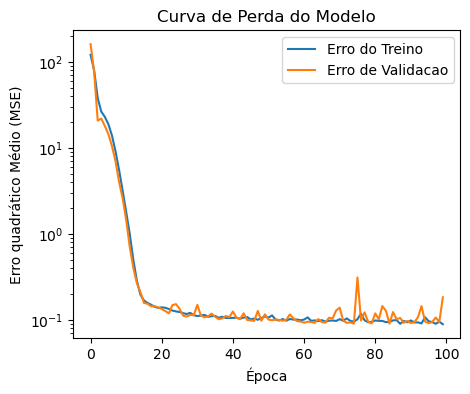

In [23]:
plt.figure(figsize=(5, 4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
plt.yscale("log")
plt.xlabel("Época")
plt.legend(["Erro do Treino", "Erro de Validacao"])
plt.show()

In [ ]:
mean_absolute_error_class = mean_absolute_error(y_test, predicts)
mean_squared_error_class = mean_squared_error(y_test, predicts)

r2_score_class = r2_score(y_test, predicts)

print(f"Métricas de Regressão:")
print(f"MAE: {mean_absolute_error_class:.2f}")  # abaixo de 0.5 seria aceitavel para preço de ações.
print(f"MSE: {mean_squared_error_class:.2f}")  # abaixo de 0.9
print(f"R2 Score: {r2_score_class:.2f}")  # 

Métricas de Regressão:
MAE: 0.39
MSE: 0.23
R2 Score: 0.95


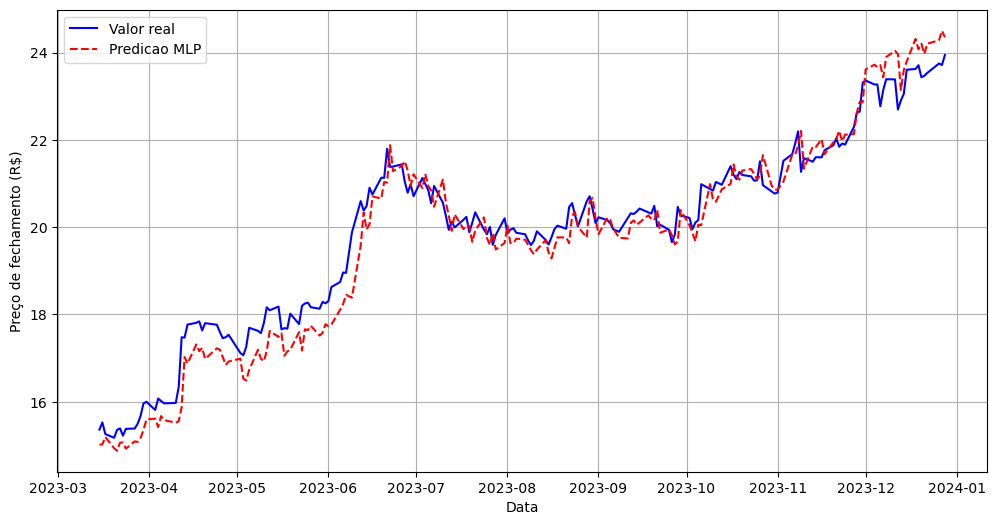

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Valor real", color="blue")
plt.plot(y_test.index, predicts, label="Predicao MLP", color="red", linestyle="--")
plt.xlabel("Data")
plt.ylabel("Preço de fechamento (R$)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
model_tf.save("models/BBS3_predict.keras")